# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import mlxtend


# Data importing and processing

In [6]:
math_q_df = pd.read_csv("./math_e.csv", delimiter=";", encoding="cp1252") #uses windows encoding due to curly apostrophe

# Data visualization
- see split of qs per student, freq of each q, freq of subtopics

Student ID
91      147
37      120
80      110
913     101
955      93
       ... 
180       1
672       1
659       1
156       1
1484      1
Name: Question ID, Length: 372, dtype: int64


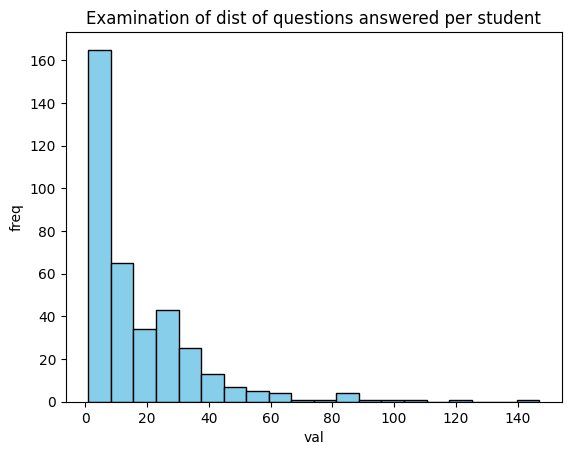

12.0


In [14]:
# get number of qs per student (distinct Question ID for each group of Student ID)
student_groups = ( 
                    math_q_df.groupby("Student ID")["Question ID"]
                    .nunique()
                    .sort_values(ascending=False)
                 )
print(student_groups)
#nt(student_groups.values)



plt.hist(student_groups.values, bins=20, color='skyblue', edgecolor='black')
plt.title(f"Examination of dist of questions answered per student")
plt.xlabel("val")
plt.ylabel("freq")
plt.show()

print(student_groups.median())


Question ID
457     59
459     58
415     57
433     57
429     55
        ..
1247     1
1248     1
1473     1
86       1
1549     1
Name: Student ID, Length: 833, dtype: int64


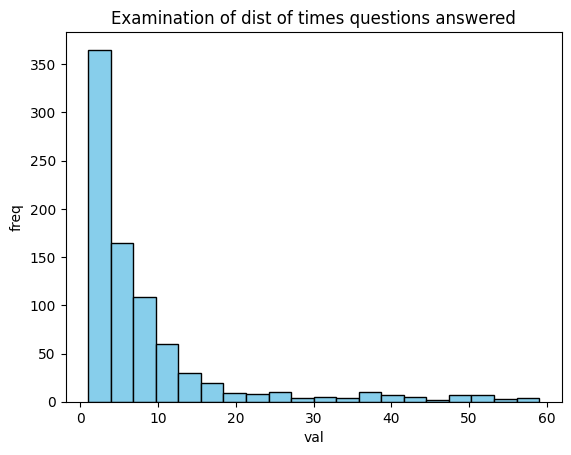

4.0


In [ ]:
# get freq of each q (bar plot in descending freq)
q_groups = ( 
                    math_q_df.groupby("Question ID")["Student ID"]
                    .nunique()
                    .sort_values(ascending=False)
                 )
print(q_groups)


plt.hist(q_groups.values, bins=20, color='skyblue', edgecolor='black')
plt.title(f"Examination of dist of times questions answered")
plt.xlabel("val")
plt.ylabel("freq")
plt.show()

print(q_groups.median())

Subtopic
Vector Spaces                                         1622
Linear Transformations                                1367
Complex Numbers                                        465
Algebraic expressions, Equations, and Inequalities     384
Linear Systems                                         331
Statistics                                             326
Derivatives                                            290
Analytic Geometry                                      282
Matrices and Determinants                              265
Partial Differentiation                                217
Elementary Geometry                                    206
Numerical Methods                                      201
Eigenvalues and Eigenvectors                           124
Probability                                            120
Integration Techniques                                 101
Differential Equations                                  99
Nonlinear Optimization                         

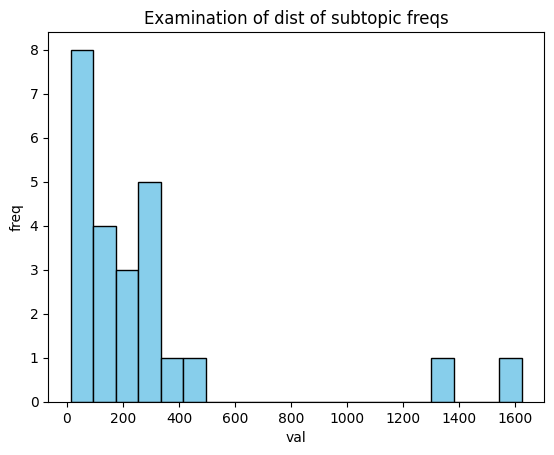

162.5


In [21]:
# get freq of each subtopic (bar plot in descending freq)
    # unique combo of student id and q id is one entry

subtopic_groups = ( 
                    math_q_df.drop_duplicates(subset=["Question ID", "Student ID", "Subtopic"])
                    .groupby("Subtopic")
                    .size()
                    .sort_values(ascending=False)
                 )
print(subtopic_groups)

# now needs to be a bar plot
plt.hist(subtopic_groups.values, bins=20, color='skyblue', edgecolor='black')
plt.title(f"Examination of dist of subtopic freqs")
plt.xlabel("val")
plt.ylabel("freq")
plt.show()

print(subtopic_groups.median())

# Split by q # and subtopics, look for associations with fp growth
- Note match by student ids, see how performance on one question predicts another (fail -> fail)

In [ ]:
# group by student id to form itemsets of failed qs

In [ ]:
# attempt to modify algo for fuzzy data (continuous category accuracy)


# interpret and vibe check rules